IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

IMPORT THE DATASET

In [6]:

sales = pd.read_csv("../data/raw/SampleSuperstore.csv")


PREVIEW THE DATASET

In [7]:

sales

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,25.2480,3,0.20,4.1028
9990,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,91.9600,2,0.00,15.6332
9991,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,258.5760,2,0.20,19.3932
9992,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,29.6000,4,0.00,13.3200


GENERATE BUSINESS UNDERSTANDING QUESTIONS

BUSINESS UNDERSTANDING QUESTIONS
1. Which region in the United States generates the highest total sales?
2. Which state had the highest total profit?
3. Which category sold the most in terms of numbers across the U.S?
4. Which category is most profitable?
5. How does discount affect the profit? Do higher discounts lead to lower or higher profits?
6. Which state shows strong sales but weak profitability?
7. What top 10 products drive the most revenue/sales?
8. Which ship mode is associated with the fastest growth in sales?
9. What products in the technology category are driving the most sales?
10. Which customer segment contributes the most to sales and profit?
11. What is the distribution of sales and profits across the country?

REVIEW THE DATA (MISSING VALUES, DUPLICATES, SHAPE, DESCRIPTIVE STATISTICS)

In [8]:
#REVIEW THE DATA
sales.head()


,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [6]:
sales.sample(5)

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
4003,Standard Class,Consumer,United States,San Antonio,Texas,78207,Central,Technology,Machines,287.910,3,0.4,33.5895
5344,Second Class,Consumer,United States,Rochester,New York,14609,East,Technology,Accessories,31.950,1,0.0,2.2365
6028,First Class,Consumer,United States,Jacksonville,North Carolina,28540,South,Office Supplies,Art,18.480,2,0.2,6.0060
588,Standard Class,Consumer,United States,Salem,Oregon,97301,West,Technology,Phones,84.784,2,0.2,-20.1362
4296,Standard Class,Corporate,United States,Los Angeles,California,90032,West,Office Supplies,Storage,54.320,4,0.0,0.5432


In [7]:
sales.shape

(9994, 13)

In [19]:
sales.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [9]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [10]:
sales.duplicated().sum()

np.int64(17)

In [11]:
# Inspect duplicated rows and create a cleaned copy
duplicate_mask = sales.duplicated(keep=False)
duplicate_rows = sales[duplicate_mask]

print(f"Total duplicated rows: {duplicate_rows.shape[0]}")
print(f"Rows before removing duplicates: {sales.shape[0]}")

sales_cleaned = sales.drop_duplicates()
print(f"Rows after removing exact duplicates: {sales_cleaned.shape[0]}")

duplicate_rows.head()


Total duplicated rows: 34
Rows before removing duplicates: 9994
Rows after removing exact duplicates: 9977


,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
568,Standard Class,Corporate,United States,Seattle,Washington,98105,West,Office Supplies,Paper,19.440,3,0.0,9.3312
591,Standard Class,Consumer,United States,Salem,Oregon,97301,West,Office Supplies,Paper,10.368,2,0.2,3.6288
935,Standard Class,Home Office,United States,Philadelphia,Pennsylvania,19120,East,Office Supplies,Paper,15.552,3,0.2,5.4432
950,Standard Class,Home Office,United States,Philadelphia,Pennsylvania,19120,East,Office Supplies,Paper,15.552,3,0.2,5.4432
1186,Standard Class,Corporate,United States,Seattle,Washington,98103,West,Office Supplies,Paper,25.920,4,0.0,12.4416


In [12]:
sales_cleaned

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,25.2480,3,0.20,4.1028
9990,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,91.9600,2,0.00,15.6332
9991,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,258.5760,2,0.20,19.3932
9992,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,29.6000,4,0.00,13.3200


In [17]:
#DESCRIPTIVE STATISTICS
sales_cleaned.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9977.000000,9977.000000,9977.000000,9977.000000,9977.00000
mean,55154.964117,230.148902,3.790719,0.156278,28.69013
std,32058.266816,623.721409,2.226657,0.206455,234.45784
min,1040.000000,0.444000,1.000000,0.000000,-6599.97800
25%,23223.000000,17.300000,2.000000,0.000000,1.72620
50%,55901.000000,54.816000,3.000000,0.200000,8.67100
75%,90008.000000,209.970000,5.000000,0.200000,29.37200
max,99301.000000,22638.480000,14.000000,0.800000,8399.97600


PERFORM VISUAL ANALYTICS TO ANSWER THE QUESTIONS WITH OBSERVATIONS

In [20]:
sales_cleaned.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

C:\Users\USER\AppData\Local\Temp\ipykernel_7612\1687503430.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_sales.values, y=region_sales.index, palette='viridis')


C:\Users\USER\AppData\Local\Temp\ipykernel_7612\1687503430.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_sales.values, y=region_sales.index, palette='viridis')


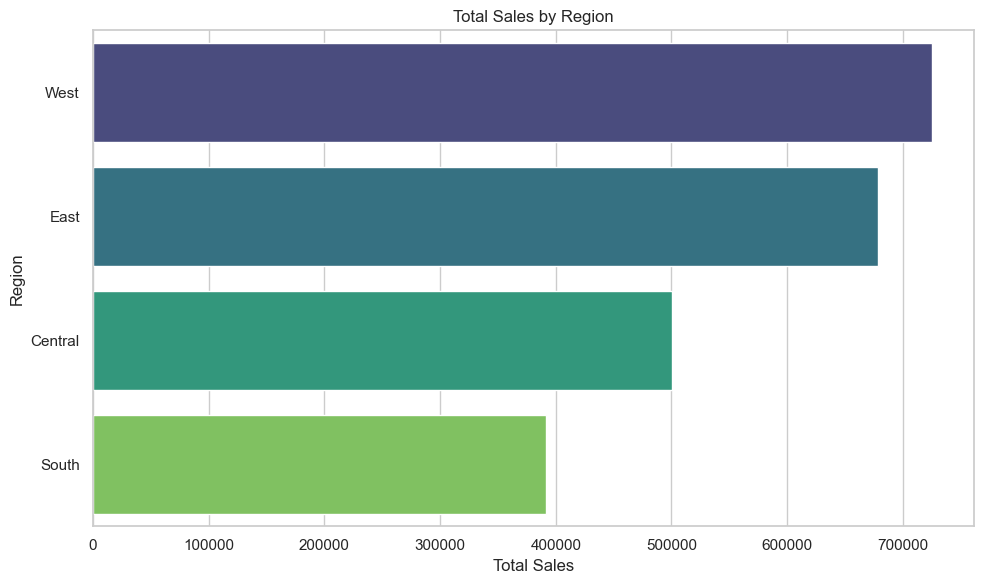

In [21]:
#1. Which region generates the highest total sales/revenue?

region_sales = sales_cleaned.groupby('Region')['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=region_sales.values, y=region_sales.index, palette='viridis')
plt.title("Total Sales by Region")
plt.xlabel("Total Sales")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

We observe that the West region of the United States is the best performing region in terms of revenue collection, surpassing the 700,000 mark. In contrast, the Southern region performed the least, with just under 400,000 in sales.

C:\Users\USER\AppData\Local\Temp\ipykernel_7612\3130867704.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_profit.values, y=state_profit.index, palette='magma')


C:\Users\USER\AppData\Local\Temp\ipykernel_7612\3130867704.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_profit.values, y=state_profit.index, palette='magma')


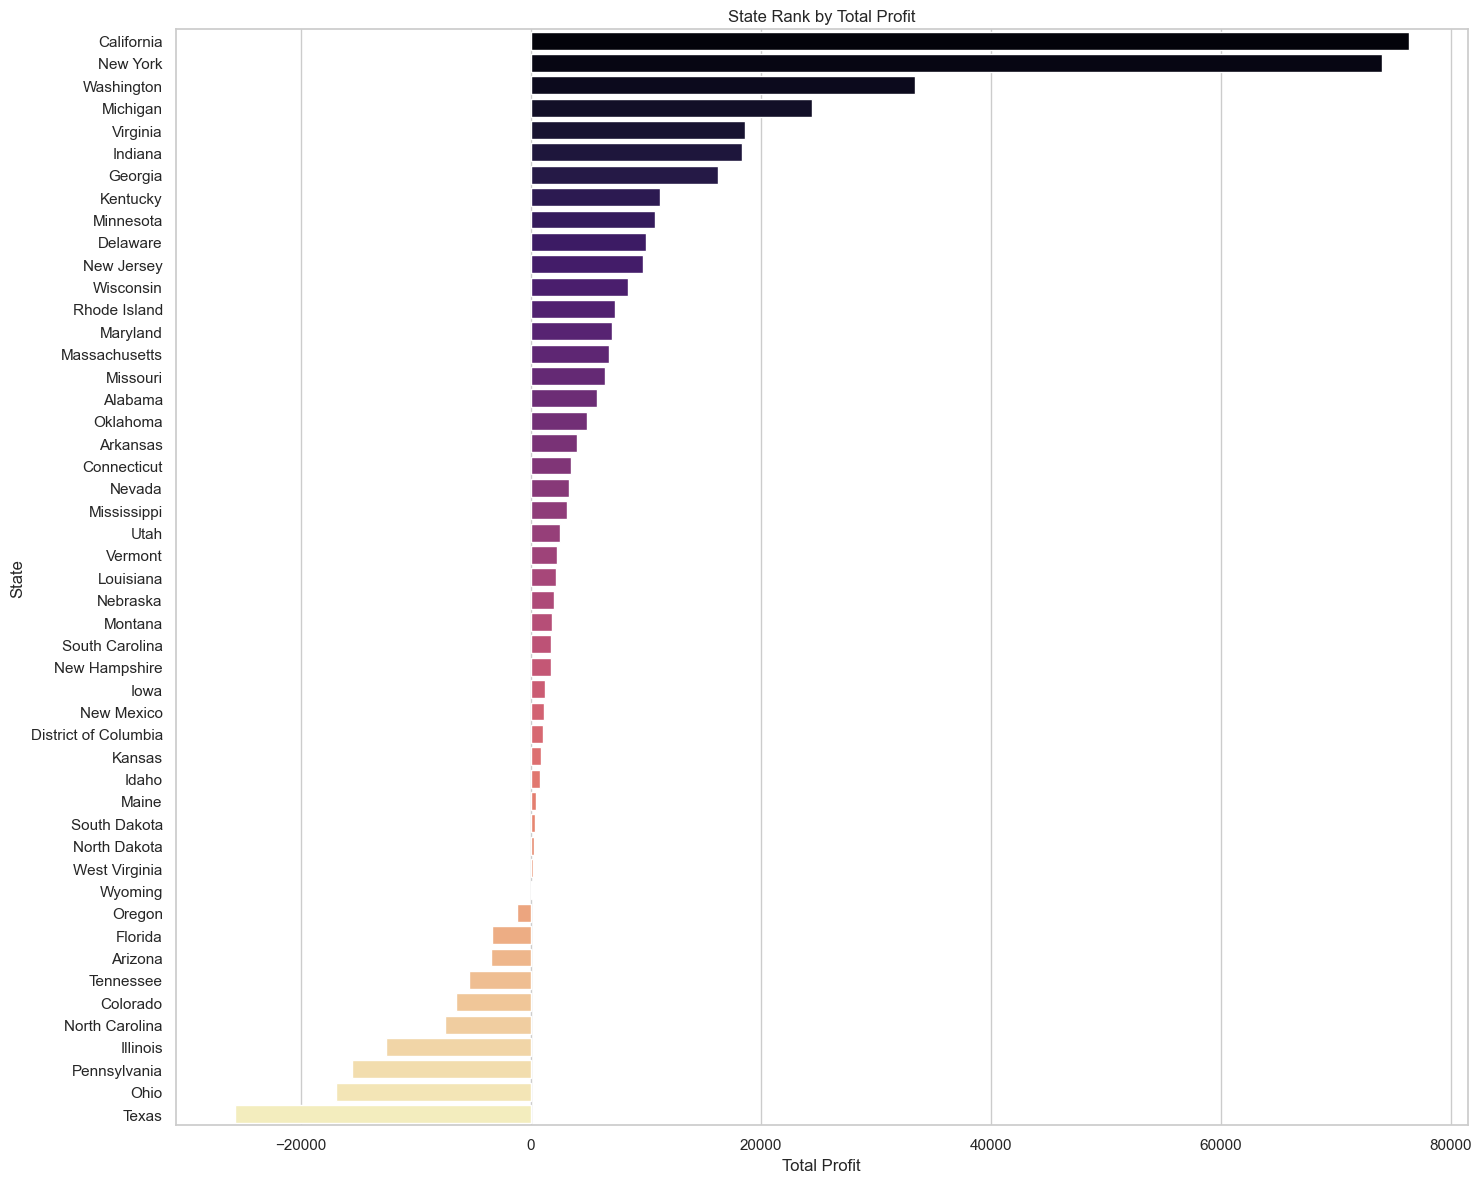

In [26]:
#2. Which state has the highest total profit?

plt.figure(figsize=(15, 12))
state_profit = sales_cleaned.groupby('State')['Profit'].sum().sort_values(ascending=False)
sns.barplot(x=state_profit.values, y=state_profit.index, palette='magma')
plt.title("State Rank by Total Profit")
plt.xlabel("Total Profit")
plt.ylabel("State")
plt.tight_layout()
plt.show()

Based on the bar plot, the top 5 states in terms of profits include California, New York, Washington, Michigan, and Virginia. The plot also informs us that some states are actually not making rofits, but are makig losses instea, which is a very huge insight!!!!

C:\Users\USER\AppData\Local\Temp\ipykernel_7612\260971117.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_quantity.values, y=category_quantity.index, palette="coolwarm")


C:\Users\USER\AppData\Local\Temp\ipykernel_7612\260971117.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_quantity.values, y=category_quantity.index, palette="coolwarm")


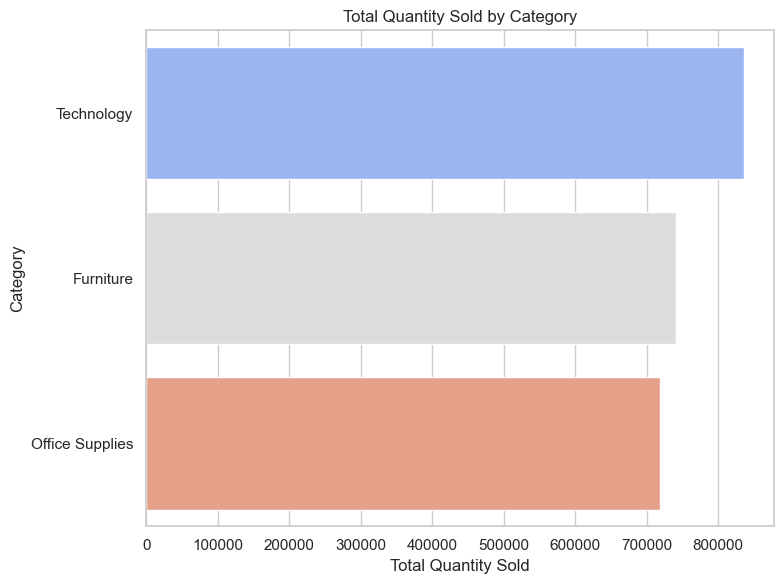

In [32]:
#3. Which category sold the most in quantity across the U.S.?

category_quantity = sales_cleaned.groupby("Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=category_quantity.values, y=category_quantity.index, palette="coolwarm")
plt.title("Total Quantity Sold by Category")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

Technology takes the lead with the most quatities sold.

C:\Users\USER\AppData\Local\Temp\ipykernel_7612\1420712753.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_profit.values, y=category_profit.index, palette="coolwarm")


C:\Users\USER\AppData\Local\Temp\ipykernel_7612\1420712753.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_profit.values, y=category_profit.index, palette="coolwarm")


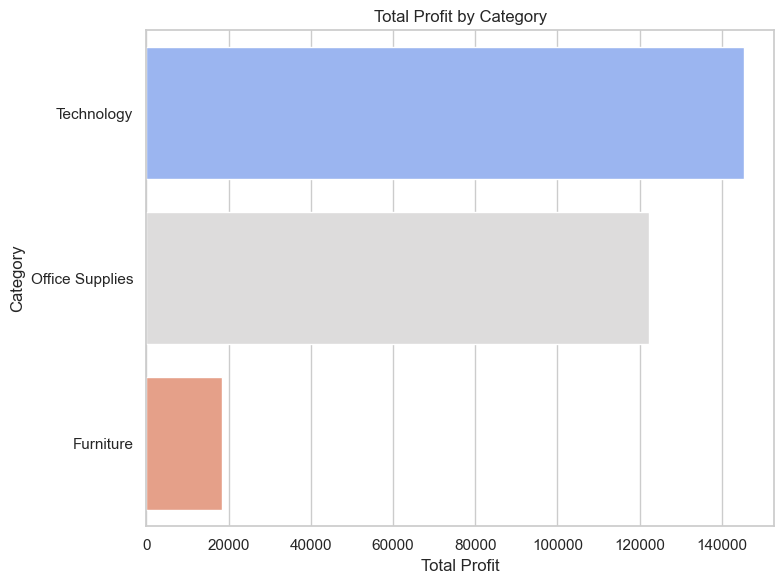

In [28]:
#4. Which category is most profitable?

category_profit = sales_cleaned.groupby("Category")["Profit"].sum().sort_values(ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(x=category_profit.values, y=category_profit.index, palette="coolwarm")
plt.title("Total Profit by Category")
plt.xlabel("Total Profit")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

This is a great insight!! This graph shows us that high sales doesn't mean high profits, with Furniture being an example.

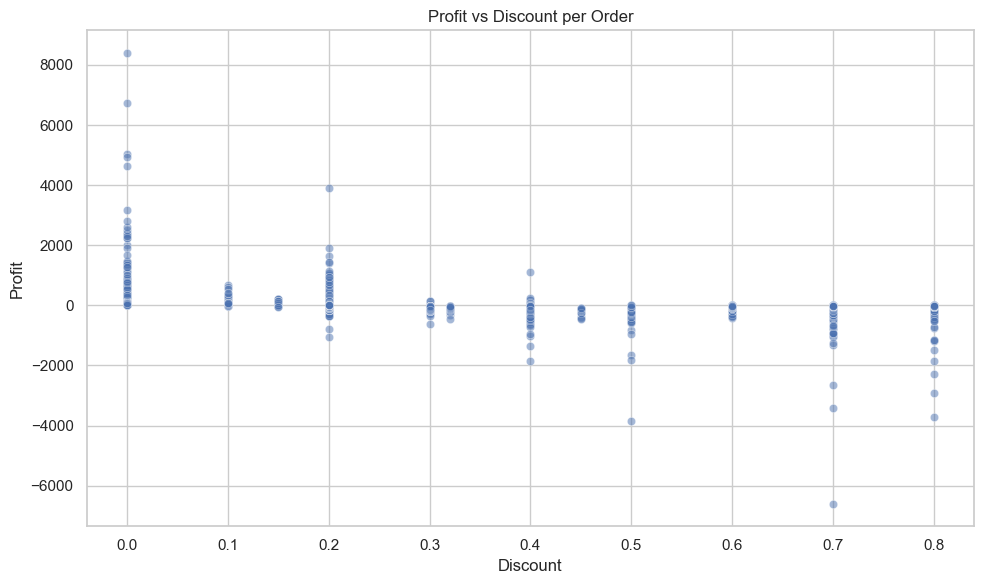

In [29]:
#5. How does discount affect profit?

plt.figure(figsize=(10, 6))
sns.scatterplot(x="Discount", y="Profit", data=sales_cleaned, alpha=0.5)
plt.title("Profit vs Discount per Order")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

It is evident that the higher the discount, the less the profit, which is well known. The overiding suggestion/proposal would be that the categories which have the least profits should reduce the amount of discounts to increase the margin of profits.

C:\Users\USER\AppData\Local\Temp\ipykernel_7612\2990431891.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weak_profit_states["total_sales"],y=weak_profit_states.index,palette="coolwarm")


C:\Users\USER\AppData\Local\Temp\ipykernel_7612\2990431891.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weak_profit_states["total_sales"],y=weak_profit_states.index,palette="coolwarm")


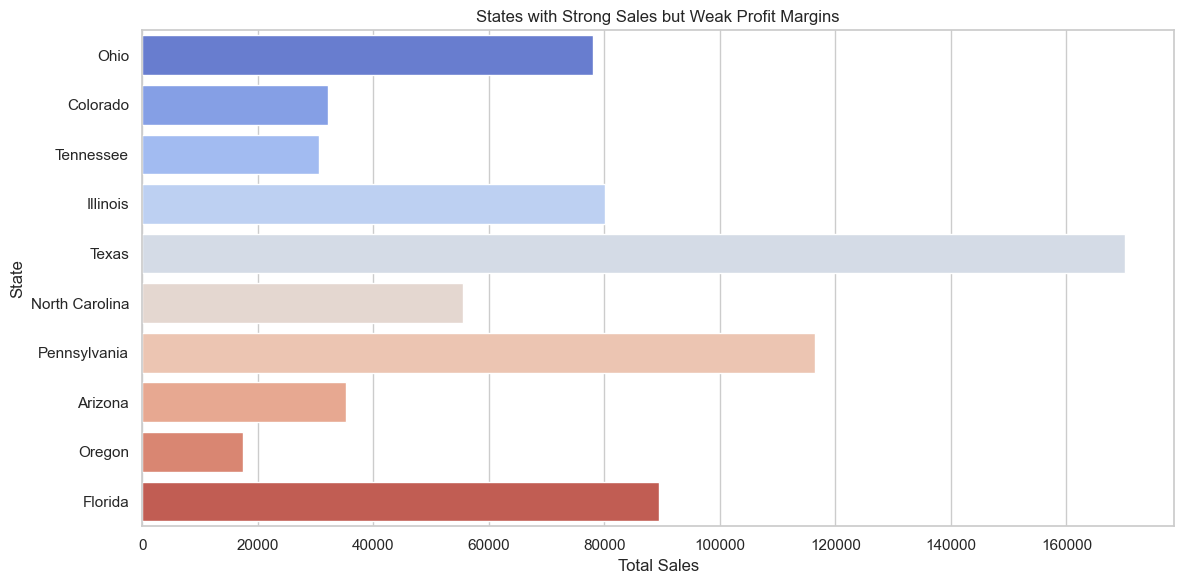

In [30]:
#6. Which state shows strong sales but weak profitability?
state_perf = sales_cleaned.groupby("State").agg(total_sales= ("Sales", "sum"), total_profit=("Profit", "sum"))
state_perf["profit_margin"] = state_perf["total_profit"]/state_perf["total_sales"]
weak_profit_states = state_perf.sort_values(by="profit_margin").head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=weak_profit_states["total_sales"],y=weak_profit_states.index,palette="coolwarm")
plt.title("States with Strong Sales but Weak Profit Margins")
plt.xlabel("Total Sales")
plt.ylabel("State")
plt.tight_layout()
plt.show()

The states in this plot are states with negative profits. This graph tells us that even though you are making great/satisfying numbers in sales, you can still have weak/negative profits.

C:\Users\USER\AppData\Local\Temp\ipykernel_7612\1925775301.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=subcat_sales.values, y=subcat_sales.index, palette="viridis")


C:\Users\USER\AppData\Local\Temp\ipykernel_7612\1925775301.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=subcat_sales.values, y=subcat_sales.index, palette="viridis")


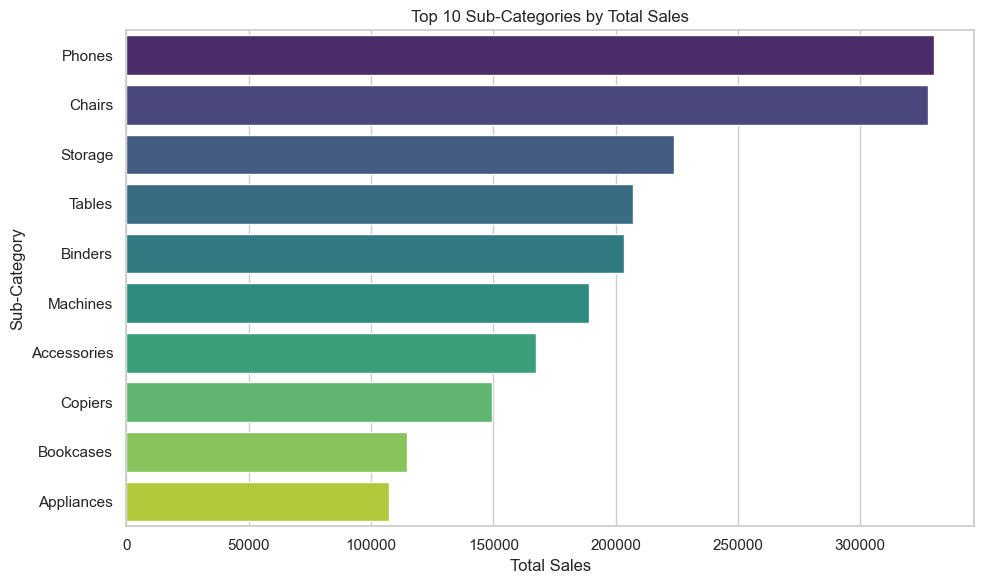

In [31]:
#7. What top 10 sub-categories drive the most revenue/sales in technology?
subcat_sales = sales_cleaned.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=subcat_sales.values, y=subcat_sales.index, palette="viridis")
plt.title("Top 10 Sub-Categories by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()

Majority of these products are under the technology category, thus contributing to its high sales.

C:\Users\USER\AppData\Local\Temp\ipykernel_7612\177066194.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ship_mode_sales.values, y=ship_mode_sales.index, palette="coolwarm")


C:\Users\USER\AppData\Local\Temp\ipykernel_7612\177066194.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ship_mode_sales.values, y=ship_mode_sales.index, palette="coolwarm")


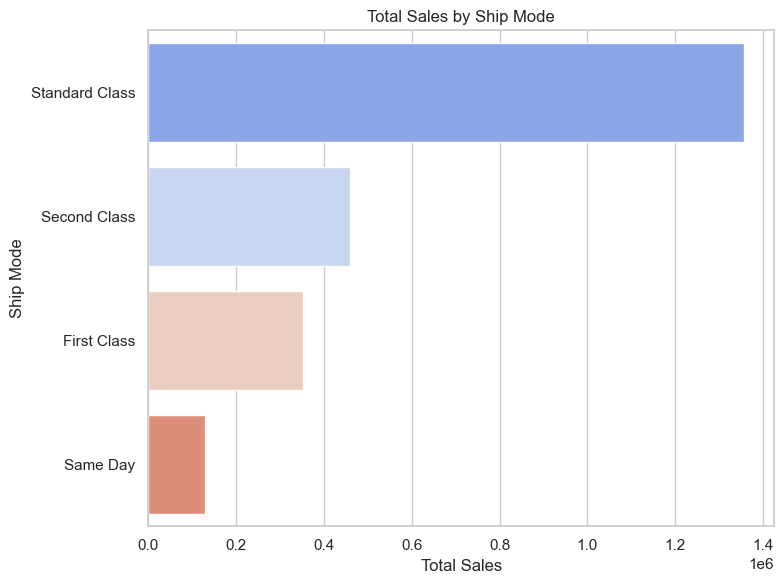

In [33]:
# 8. Which ship mode is associated with the strongest sales performance?
ship_mode_sales = sales_cleaned.groupby("Ship Mode")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=ship_mode_sales.values, y=ship_mode_sales.index, palette="coolwarm")
plt.title("Total Sales by Ship Mode")
plt.xlabel("Total Sales")
plt.ylabel("Ship Mode")
plt.tight_layout()
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_7612\500695582.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tech_rankings["Total_Sales"], y=tech_rankings.index, palette="rocket")


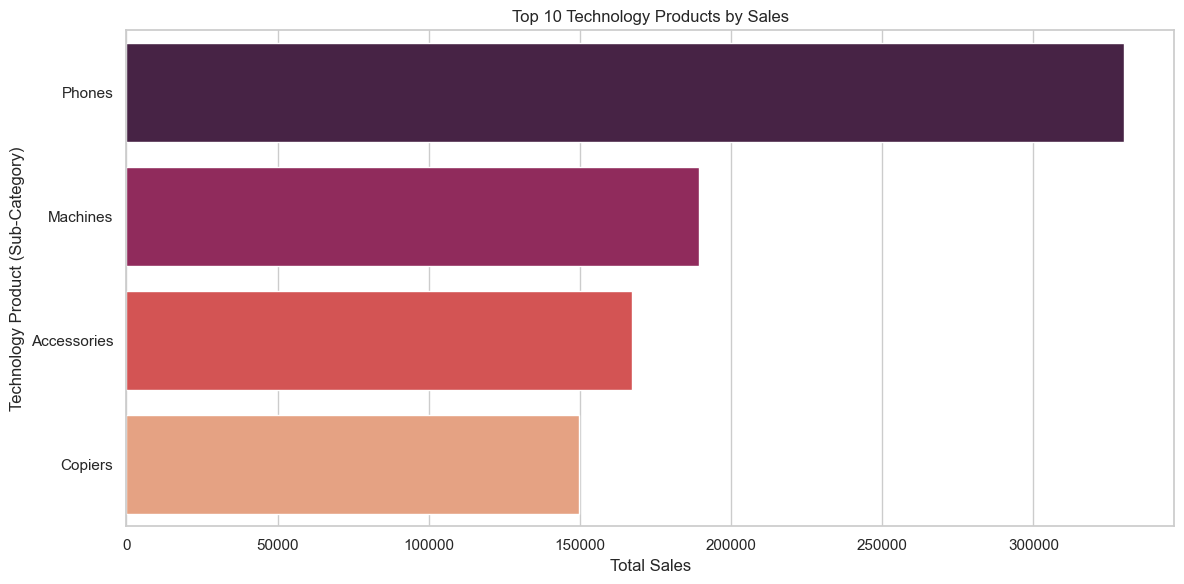

In [ ]:
#9. What products in the technology category are driving the most sales?
tech_products = sales_cleaned[sales_cleaned["Category"] == "Technology"].copy()

tech_rankings = (tech_products.groupby("Sub-Category").agg(Total_Sales=("Sales", "sum"),Total_Profit=("Profit", "sum"),Total_Quantity=("Quantity", "sum")).sort_values("Total_Sales", ascending=False).head(10))

tech_rankings

plt.figure(figsize=(12, 6))
sns.barplot(x=tech_rankings["Total_Sales"], y=tech_rankings.index, palette="rocket")
plt.title("Top 10 Technology Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Technology Product (Sub-Category)")
plt.tight_layout()
plt.show()


C:\Users\USER\AppData\Local\Temp\ipykernel_7612\3662474047.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_sales.index, y=segment_sales.values, palette="Set2")


C:\Users\USER\AppData\Local\Temp\ipykernel_7612\3662474047.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_sales.index, y=segment_sales.values, palette="Set2")


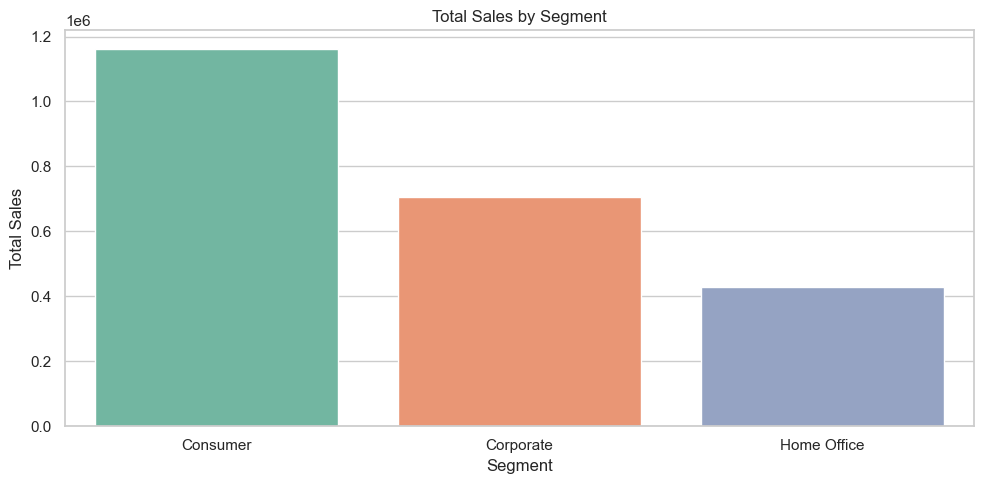

C:\Users\USER\AppData\Local\Temp\ipykernel_7612\3662474047.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_sales.index, y=segment_sales.values, palette="Set2")


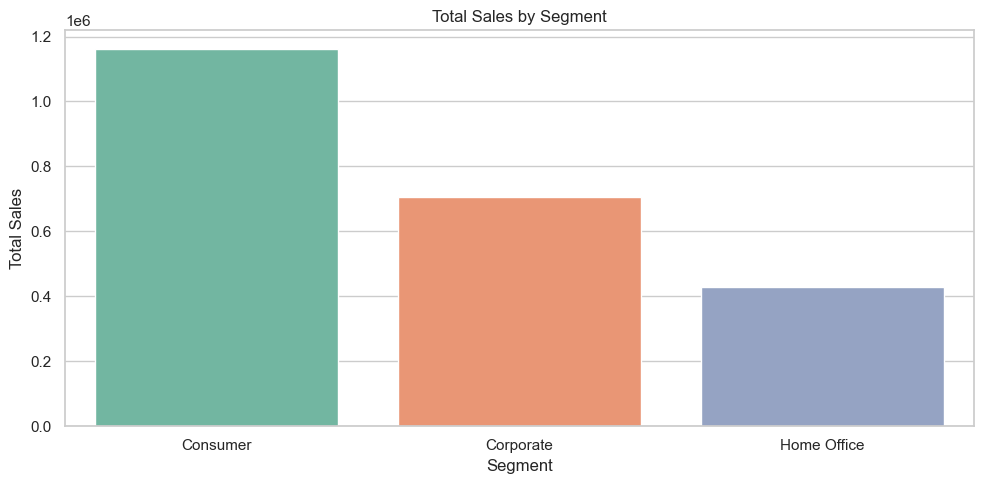

C:\Users\USER\AppData\Local\Temp\ipykernel_7612\3662474047.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_profit.index, y=segment_profit.values, palette="Set2")


C:\Users\USER\AppData\Local\Temp\ipykernel_7612\3662474047.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_sales.index, y=segment_sales.values, palette="Set2")


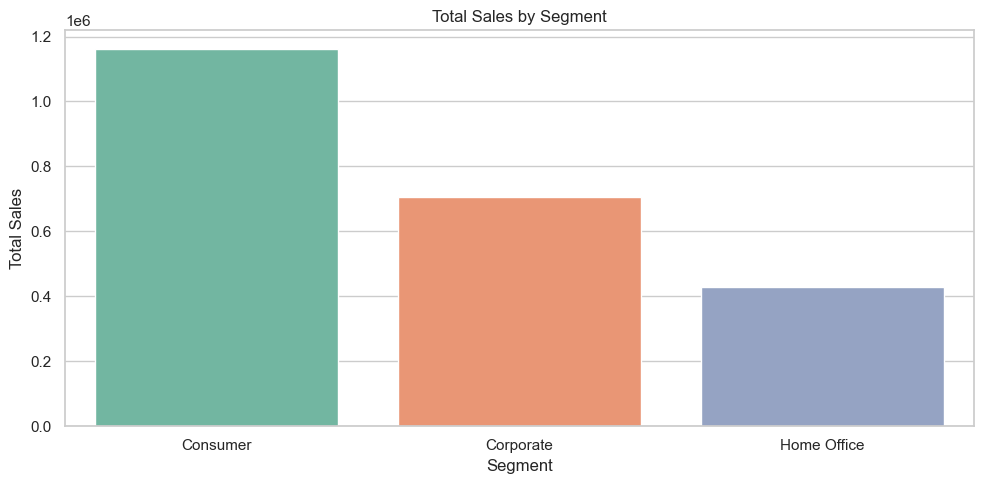

C:\Users\USER\AppData\Local\Temp\ipykernel_7612\3662474047.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_profit.index, y=segment_profit.values, palette="Set2")


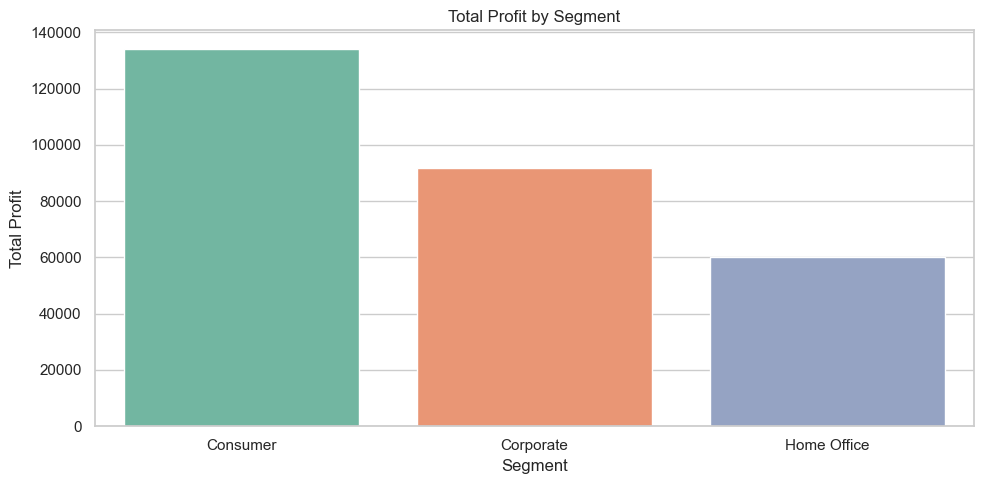

In [36]:
#10. Which customer segment contributes the most to sales and profit?

segment_sales = sales_cleaned.groupby("Segment")["Sales"].sum().sort_values(ascending=False)
segment_profit = sales_cleaned.groupby("Segment")["Profit"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=segment_sales.index, y=segment_sales.values, palette="Set2")
plt.title("Total Sales by Segment")
plt.xlabel("Segment")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(x=segment_profit.index, y=segment_profit.values, palette="Set2")
plt.title("Total Profit by Segment")
plt.xlabel("Segment")
plt.ylabel("Total Profit")
plt.tight_layout()
plt.show()

In [13]:
#11. What is the distribution of sales and profits across the country?
state_summary = (
    sales_cleaned.groupby("State")
    .agg(Total_Sales=("Sales", "sum"), Total_Profit=("Profit", "sum"))
    .reset_index()
)

state_to_abbrev = {
    "Alabama":"AL","Alaska":"AK","Arizona":"AZ","Arkansas":"AR","California":"CA",
    "Colorado":"CO","Connecticut":"CT","Delaware":"DE","Florida":"FL","Georgia":"GA",
    "Hawaii":"HI","Idaho":"ID","Illinois":"IL","Indiana":"IN","Iowa":"IA",
    "Kansas":"KS","Kentucky":"KY","Louisiana":"LA","Maine":"ME","Maryland":"MD",
    "Massachusetts":"MA","Michigan":"MI","Minnesota":"MN","Mississippi":"MS","Missouri":"MO",
    "Montana":"MT","Nebraska":"NE","Nevada":"NV","New Hampshire":"NH","New Jersey":"NJ",
    "New Mexico":"NM","New York":"NY","North Carolina":"NC","North Dakota":"ND","Ohio":"OH",
    "Oklahoma":"OK","Oregon":"OR","Pennsylvania":"PA","Rhode Island":"RI","South Carolina":"SC",
    "South Dakota":"SD","Tennessee":"TN","Texas":"TX","Utah":"UT","Vermont":"VT",
    "Virginia":"VA","Washington":"WA","West Virginia":"WV","Wisconsin":"WI","Wyoming":"WY"
}

state_summary["Code"] = state_summary["State"].map(state_to_abbrev)

import plotly.express as px
from IPython.display import HTML, display
from pathlib import Path

fig_sales = px.choropleth(
    state_summary,
    locations="Code",
    locationmode="USA-states",
    color="Total_Sales",
    scope="usa",
    hover_name="State",
    color_continuous_scale="Viridis",
    title="Total Sales by State"
)

output_file = Path("total_sales_by_state.html")
fig_sales.write_html(output_file, include_plotlyjs="cdn")

with open(output_file, "r", encoding="utf-8") as f:
    html_content = f.read()

display(HTML(html_content))


In [14]:
import pandas as pd
from pathlib import Path

output_path = Path("../data/processed/sales_cleaned.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)

sales_cleaned.to_csv(output_path, index=False)

print(f"Saved cleaned data to {output_path}")

Saved cleaned data to ..\data\processed\sales_cleaned.csv
